<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)
A = 0.1; sigma = 0.2
x1 = np.pi/2; x2 = 3*np.pi/2
theta_vals = np.linspace(0, 2*np.pi, 32)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def clip_guard(phi, max_abs=1.0):
    m = np.max(np.abs(phi))
    return phi * (max_abs / m) if m > max_abs else phi

def evolve(phi, steps=250):
    dt = 0.02; gamma = 0.001; lam = 0.5; delta = 0.05; tau = 0.08
    for _ in range(steps):
        collapse = delta * (np.abs(phi) > tau)
        phi = phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3) - collapse
        phi = clip_guard(phi)
    return phi

def entropy(phi):
    p = phi**2 / np.sum(phi**2)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def collapse_index(phi, eps=1e-3):
    return np.sum(np.abs(phi) < eps) / len(phi)

def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

S_vals = []; C_vals = []; F_vals = []

for theta in theta_vals:
    A1 = gaussian(x1, sigma, A)
    A2 = gaussian(x2, sigma, A)
    phi0 = A1 + A2 * np.cos(theta)
    phi_final = evolve(phi0.copy())
    S_vals.append(entropy(phi_final))
    C_vals.append(collapse_index(phi_final))
    F_vals.append(correlation(phi_final, phi0))


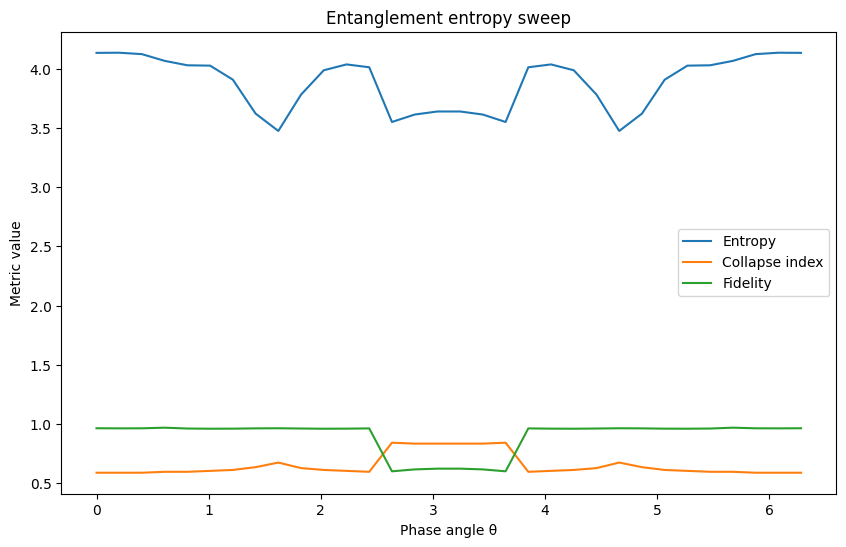

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(theta_vals, S_vals, label="Entropy")
plt.plot(theta_vals, C_vals, label="Collapse index")
plt.plot(theta_vals, F_vals, label="Fidelity")
plt.xlabel("Phase angle θ")
plt.ylabel("Metric value")
plt.title("Entanglement entropy sweep")
plt.legend()
plt.show()
